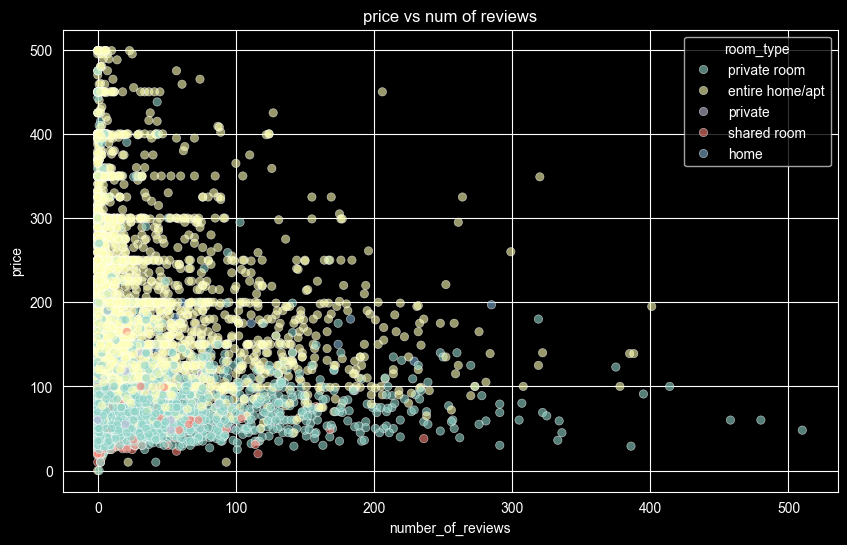

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

airbnb = pd.read_csv('data/airbnb.csv')

airbnb['room_type'] = airbnb['room_type'].str.lower().str.strip()
airbnb['price'] = airbnb['price'].str.strip("$").astype('float')

# only keep records with price < 500 so that outliers won't stretch the plot
airbnb_filtered = airbnb[airbnb['price'] < 500].copy()
plt.figure(figsize=(10, 6))
sns.scatterplot(data=airbnb_filtered, x='number_of_reviews', y='price', hue='room_type', alpha=0.6)

plt.title('price vs num of reviews')
plt.xlabel('number_of_reviews')
plt.ylabel('price')

plt.show()

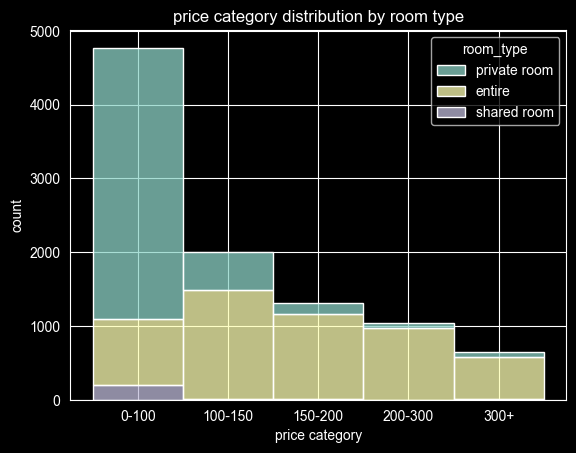

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

airbnb = pd.read_csv('data/airbnb.csv')

mappings = {
    'private room': 'private room',
    'private': 'private room',
    'entire home/apt': 'entire',
    'shared room': 'shared room',
    'home': 'entire'
}

airbnb['price'] = airbnb['price'].str.strip("$").astype(float)
airbnb['room_type'] = airbnb['room_type'].str.lower().str.strip().replace(mappings)

my_prices = [0, 100,150,200,300, float('inf')]
labels = ['0-100', '100-150', '150-200', '200-300', '300+']
airbnb['price_category'] = pd.cut(airbnb['price'], bins=my_prices, labels=labels)
sns.histplot(data = airbnb , x='price_category', hue='room_type', multiple='stack')
plt.title('price category distribution by room type')
plt.xlabel('price category')
plt.ylabel('count')
plt.show()
